## Regularization 

<ul>
<li>A model will have a low accuracy if it is overfitting. </li>
<li>Overfitting occurs when model is trying too hard to capture the noise (samples that don't represent true pattern)
    in your training dataset.</li>
<li>When model is more flexible, it is prone to overfitting</li>
<li>Regularization shrinks the coefficients (parameter or slops) towards zero to discourages a more complex or flexible model, so as to avoid the risk of overfitting</li>
    <li>Ridge and Lasso are two options </li>
    <li>Regularization strength is provided by parameter <b>alpha</b></li>
</ul>    

In [1]:
# import pandas library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import warnings 
warnings.filterwarnings(action='ignore')

In [18]:
X_train = pd.DataFrame({'sqft':[1000,2000,3000,4000,5000]})
y_train = pd.Series([40,65,70,80,85])
X_test = pd.DataFrame({'sqft':[4200,3000,4200,2100] })
y_test = pd.Series([65,45,80,60])

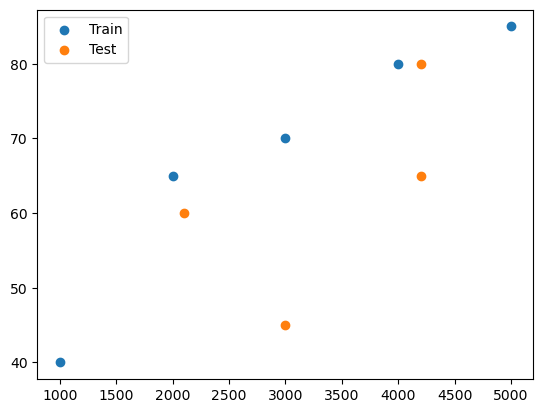

In [19]:
plt.scatter(X_train.sqft, y_train, label='Train')
plt.scatter(X_test.sqft, y_test, label = 'Test')
plt.legend()

### LinearRegression

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [21]:
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)

LinearRegression()

In [22]:
lr_model.coef_

array([0.0105])

In [23]:
y_pred = lr_model.predict(X_train)

In [24]:
mse = mean_squared_error(y_train,y_pred)
print("MSE      : ", mse)
print("RMSE     : ", np.sqrt(mse))
print("R2 Score : ", r2_score(y_train, y_pred))

MSE      :  25.49999999999998
RMSE     :  5.049752469181037
R2 Score :  0.8963414634146343


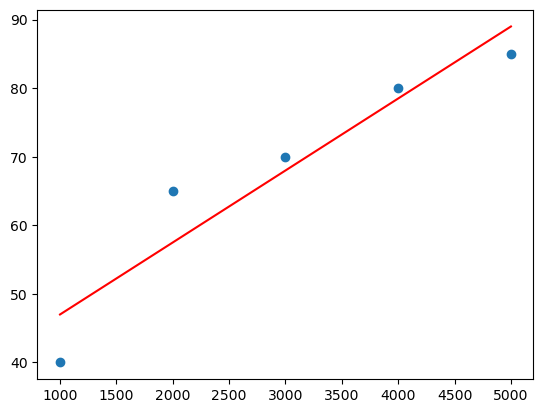

In [25]:
plt.scatter(X_train.sqft,y_train)
plt.plot(X_train.sqft,y_pred,'r-')

In [26]:
y_pred = lr_model.predict(X_test)

In [27]:
mse = mean_squared_error(y_test,y_pred)
print("MSE      : ", mse)
print("RMSE     : ", np.sqrt(mse))
print("R2 Score : ", r2_score(y_test, y_pred))

MSE      :  193.70562499999994
RMSE     :  13.917816818739926
R2 Score :  -0.2397159999999996


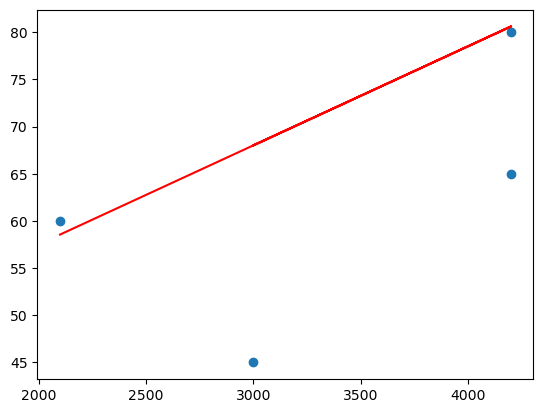

In [28]:
plt.scatter(X_test.sqft,y_test)
plt.plot(X_test.sqft,y_pred,'r-')

## Ridge Regression (L2)

In [29]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [30]:
# ss = StandardScaler()
# X_train_scaled = ss.fit_transform(X_train)

In [31]:
ridge = Ridge(alpha=5.0)
ridge.fit(X_train,y_train)

Ridge(alpha=5.0)

In [32]:
ridge.coef_

array([0.01049999])

In [33]:
y_pred = ridge.predict(X_train)

In [34]:
mse = mean_squared_error(y_train,y_pred)
print("MSE      : ", mse)
print("RMSE     : ", np.sqrt(mse))
print("R2 Score : ", r2_score(y_train, y_pred))

MSE      :  25.500000000055145
RMSE     :  5.049752469186499
R2 Score :  0.89634146341441


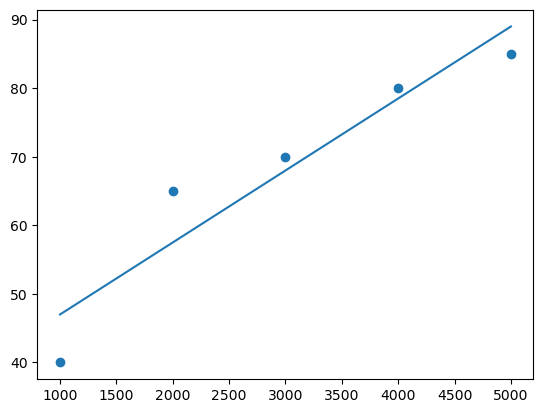

In [35]:
plt.scatter(X_train.sqft,y_train)
plt.plot(X_train.sqft,y_pred)

In [38]:
y_pred = ridge.predict(X_test)

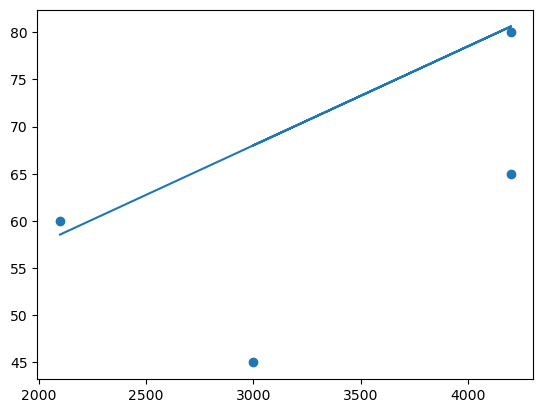

In [39]:
plt.scatter(X_test.sqft,y_test)
plt.plot(X_test.sqft,y_pred)

In [40]:
mse = mean_squared_error(y_test,y_pred)
print("MSE      : ", mse)
print("RMSE     : ", np.sqrt(mse))
print("R2 Score : ", r2_score(y_test, y_pred))

MSE      :  193.70557054442767
RMSE     :  13.917814862413843
R2 Score :  -0.23971565148433704


## LassoCV

In [41]:
from sklearn.linear_model import LassoCV

In [42]:
lasso = LassoCV(cv = 3, alphas = [.25, .5, 1, 2,4,6])
lasso.fit(X_train,y_train)

LassoCV(alphas=[0.25, 0.5, 1, 2, 4, 6], cv=3)

In [43]:
lasso.coef_

array([0.01049988])

In [44]:
lasso.alpha_

0.25

In [45]:
y_pred = lasso.predict(X_train)

In [46]:
mse = mean_squared_error(y_train,y_pred)
print("MSE      : ", mse)
print("RMSE     : ", np.sqrt(mse))
print("R2 Score : ", r2_score(y_train, y_pred))

MSE      :  25.50000003125002
RMSE     :  5.0497524722752525
R2 Score :  0.8963414632876016


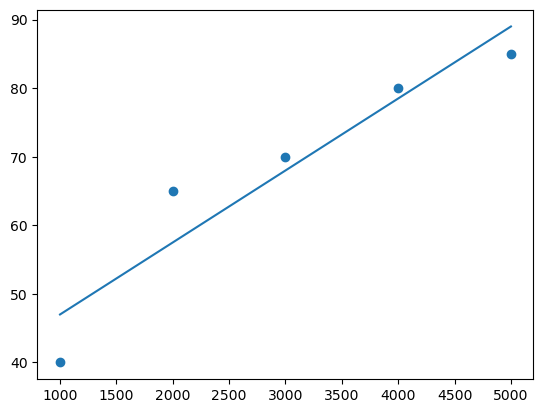

In [47]:
plt.scatter(X_train.sqft,y_train)
plt.plot(X_train.sqft,y_pred)

In [48]:
y_pred = lasso.predict(X_test)

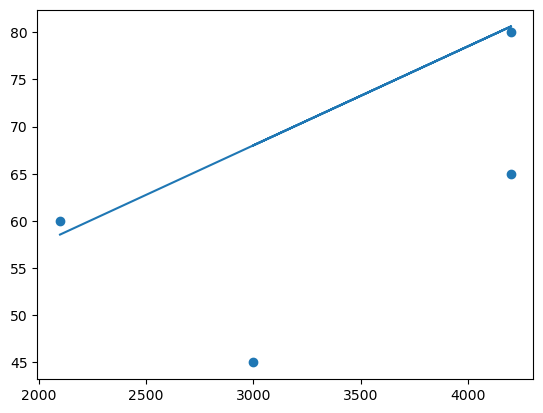

In [49]:
plt.scatter(X_test.sqft,y_test)
plt.plot(X_test.sqft,y_pred)

In [50]:
mse = mean_squared_error(y_test,y_pred)
print("MSE      : ", mse)
print("RMSE     : ", np.sqrt(mse))
print("R2 Score : ", r2_score(y_test, y_pred))

MSE      :  193.70432845191408
RMSE     :  13.917770239945552
R2 Score :  -0.23970770209225
